# より大きな問題へ

In [4]:
import os, sys
sys.path.append(os.pardir)
import numpy as np
import common.gridworld_render as render_helper

class GridWorld:
    """3×4マスのグリッドワールド
    
    インスタンス
    """
    def __init__(self):
        self.action_space = [0, 1, 2, 3]    # 行動の候補（その詳細は`self.action_meaning`にて定義している。
        self.action_meaning = {     # 行動の候補に対応した行動の形態の詳細
            0: "UP",
            1: "DOWN",
            2: "LEFT",
            3: "RIGHT",
        }

        self.reward_map = np.array( # 報酬マップ（マップの各マスに対する報酬。リンゴがあるところは`1.0`で爆弾があるところには`-1.0`が報酬として設定されている。
            [[0, 0, 0, 1.0],
             [0, None, 0, -1.0],
             [0, 0, 0, 0]]
        )
        self.goal_state = (0, 3)    # ゴールの位置（ここに位置するとタスクが終了し、初期位置に戻る）
        self.wall_state = (1, 1)    # 入れない壁が存在する位置
        self.start_state = (2, 0)   # エージェントの初期位置
        self.agent_state = self.start_state # エージェントの現在の状態（初期値はスタート位置に存在している）
    
    @property   # 直後のメソッドをインスタンス変数として扱うことができる！
    def height(self):
        return len(self.reward_map) # self.reward_mapの0次元目の長さ
    
    @property
    def width(self):
        return len(self.reward_map[0])  # self.reward_mapの`[0, :]`成分（0行目）の長さ
    
    @property
    def shape(self):
        return self.reward_map.shape    # self.reward_mapの形状（`(3, 4)`）
    
    def actions(self):   # 全ての行動にアクセス
        return self.action_space    # [0, 1, 2, 3]
    
    def states(self):   # 全ての状態にアクセス（一回の処理毎に出力する）
        for h in range(self.height):    # ここで、メソッドを`self.height`というインスタンス変数として使用している！
            for w in range(self.width): # ここでも！
                yield (h, w)            # yieldを用いることで、一回の実行毎にfor文で得られる結果を返すことができる。

    # 環境の状態遷移を表すメソッドと報酬関数のメソッドを実装
    
    def next_state(self, state, action):    # 環境の状態遷移を表すメソッド
        # 1. 移動先の場所の計算
        action_move_map = [(-1, 0), (1, 0), (0, -1), (0, 1)]    # 場所の変化量（左から「DOWN」「UP」「LEFT」「RIGHT」。数学の座標とはxとyが逆なので注意！）
        move = action_move_map[action]  # どちらに動くか決定（左右上下のいずれか）
        next_state = (state[0] + move[0], state[1] + move[1])   # 次の状態に遷移する（y軸, x軸）
        ny, nx = next_state # 次の状態のx座標（nx）とy座標（ny）が設定される。

        # 2. 移動先がグリッドワールドの枠の外か、それとも移動先が壁か？
        if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height:   # 次の状態が枠外のとき
            next_state = state  # 状態をもとに戻す
        elif next_state == self.wall_state: # 次の状態が壁のとき
            next_state = state  # 状態をもとに戻す
        
        # 3. 次の状態を返す
        return next_state   # 今回は状態遷移が決定論的なので、そのまま（確率1で）次の状態を返す。
    
    def reward(self, state, action, next_state):    # 報酬関数を表すメソッド
        return self.reward_map[next_state]  # この本では報酬関数を決定論的なものとみなしているので、報酬をそのまま返す。しかし今回は状態遷移が決定論的であるため、次の状態のみによって報酬を決定している点に注意。
    
    # 次の関数はグリッドを可視化するものであり、メソッドの定義の中身はあまり重要ではない
    def render_v(self, v=None, policy=None, print_value=True):
        renderer = render_helper.Renderer(self.reward_map, self.goal_state,
                                          self.wall_state)
        renderer.render_v(v, policy, print_value)

In [5]:
env = GridWorld()

# env.height()ではなく、env.heightとして使用できる。
print(env.height)
print(env.width)
print(env.shape)

3
4
(3, 4)


In [6]:
# GridWorldクラスのactionsとstatesというメソッドの使用例
for action in env.actions():
    print(action)

print('===')

for state in env.states():
    print(state)

0
1
2
3
===
(0, 0)
(0, 1)
(0, 2)
(0, 3)
(1, 0)
(1, 1)
(1, 2)
(1, 3)
(2, 0)
(2, 1)
(2, 2)
(2, 3)


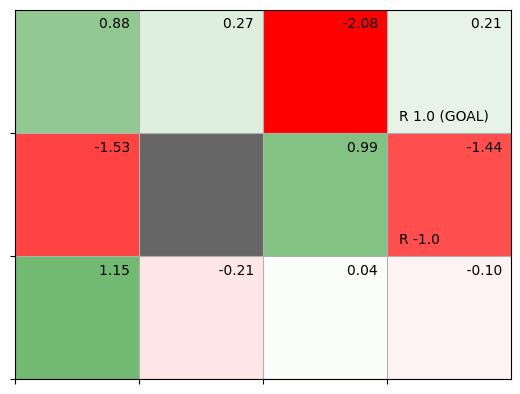

In [7]:
env = GridWorld()
V = {}
for state in env.states():
    V[state] = np.random.randn()    # ダミーの状態価値関数

env.render_v(V)

In [ ]:
import sys, os
sys.path.append(os.pardir)
from common.gridworld import GridWorld

env = GridWorld()
V = {}  # 価値関数の用意

# ディクショナリの要素の初期化
for state in env.states():
    V[state] = 0

state = (1, 2)
print(V[state])
print(V)

0
{(0, 0): 0, (0, 1): 0, (0, 2): 0, (0, 3): 0, (1, 0): 0, (1, 1): 0, (1, 2): 0, (1, 3): 0, (2, 0): 0, (2, 1): 0, (2, 2): 0, (2, 3): 0}


In [ ]:
# collections.defaultdictを用いた場合
import sys, os
sys.path.append(os.pardir)
from collections import defaultdict
from common.gridworld import GridWorld

env = GridWorld()
V = defaultdict(lambda: 0)  # lambdaによってデフォルト値を定義
# このようなラムダ式の使い方から考えると、これは引数を持たない使い捨てメソッドの返り値が必ず0になるということか。

# for文による初期化をする必要が無い。

state = (1, 2)
print(V[state])
print(V)

0
defaultdict(<function <lambda> at 0x0000016BBA318B80>, {(1, 2): 0})


In [ ]:
# lambda式について
import numpy as np
a = lambda x: x * 2
print(a(5))

list(map(lambda x: 2 * x, [1, 2, 3]))
# map(lambda x: x * 2, [1, 2, 3])

list(filter(lambda x: x % 2 == 0, [1, 2, 3, 4, 5]))
# list(filter(lambda x: x % 2 == 0, np.array([1, 2, 3, 4, 5])))

fruits = [("apple", 150), ("banana", 100), ("cherry", 200)]
sorted(fruits, key=lambda x: x[1])
# sorted(fruits)

10


[('apple', 150), ('banana', 100), ('cherry', 200)]

In [ ]:
# ラムダ式が引数を二つ取るとき
lambda x, y: x + y

from functools import reduce
reduce(lambda x, y: x + y, [1, 2, 3, 4, 5])

In [ ]:
# 行動の確率分布をpiに格納（difaultdictとして）
# ランダムな方策を実装したに他ならない
pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})

state = (0, 1)
print(pi[state])
# piは状態を与えると、その状態における行動の確率分布を返す

{0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}


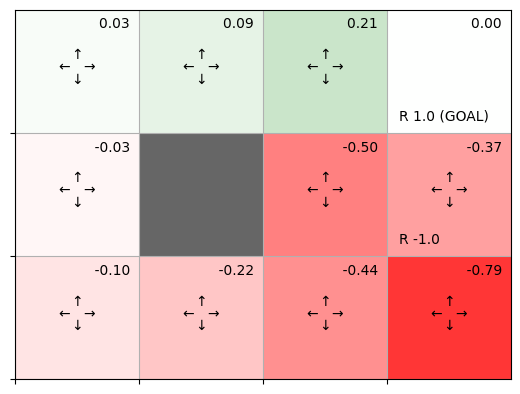

In [19]:
# これまでに実装したGridWorldクラスとpolicy_evalメソッドを使って、方策評価を行う。
from common.gridworld import GridWorld
from ch04.policy_eval import *

env = GridWorld()
gamma = 0.9

pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
V = defaultdict(lambda: 0)

V = policy_eval(pi, V, env, gamma)
env.render_v(V, pi)